In [ ]:
import pandas as pd
import seaborn as sns
import numpy as np
from matplotlib import pyplot as plt
from dataloader import (
    load_gene_table,
    load_deseq_table,
    merge_deseq_tables,
    load_stringtie_coverage,
    calculate_coverage_rescue,
    fetch_coverage,
    fetch_exons,
)
from variant_density import calculate_gene_variant_density

# define paths to data files
DATA_DIR = "../data"
GENE_TABLE_PATH = DATA_DIR + "/TAIR10/ensembl_gene_names.txt"
DESEQ2_RESULTS_DIR = DATA_DIR + "/results/latest/deseq2/"
STRINGTIE_RESULTS_DIR = DATA_DIR + "/results/latest/stringtie/"
CRAM_DIR = DATA_DIR + "/results/latest/cram/"
BIGWIG_DIR = DATA_DIR + "/results/latest/bigwig/"
# specific definitions for this experiment
LINEAR_GENOME_NAME = "TAIR10"
PANGENOME_NAME = "asia"
TARGET_ACCESSION_NUM = "10015"  # this is the ID for Ara-1 (Shahdara-1), the accession used in this experiment
TARGET_VARIANTS_VCF = DATA_DIR + f"/VCF/accession_{TARGET_ACCESSION_NUM}.vcf.gz"
ANNOTATIONS_GTF = DATA_DIR + "/TAIR10/Araport11_GTF_genes_transposons.Mar202021.gtf.gz"
# sample name and conditions for the rnaseq experiment (Ara-1 plants were exposed to drought stress)
SAMPLE_INFO = [
    {"sample_name": "A", "condition": "control"},
    {"sample_name": "B", "condition": "control"},
    {"sample_name": "C", "condition": "stressed"},
    {"sample_name": "D", "condition": "stressed"},
]

genes_of_interest = [
    "AT4G17490",
    "AT1G67360",
    "AT4G13395",
]  # drought related genes warranting further investigation

In [2]:
# load gene names from pregenerated table from ensembl biomart 
gene_table = load_gene_table(GENE_TABLE_PATH)
gene_table

,Gene description,Gene name,Chromosome/scaffold name,Gene start (bp),Gene end (bp)
Gene stable ID,,,,,
AT3G05780,lon protease 3,LON3,3,1714941,1719608
AT1G24405,uncharacterized protein,AT1G24405,1,8654945,8655662
AT2G27490,dephospho-CoA kinase family,ATCOAE,2,11748015,11750488
AT3G13276,uncharacterized protein,AT3G13276,3,4294341,4294860
AT1G71740,nucleolar protein,AT1G71740,1,26987245,26987637
...,...,...,...,...,...
AT4G25880,pumilio 6,PUM6,4,13154708,13159382
AT1G30814,uncharacterized protein,AT1G30814,1,10942648,10944727
AT2G43120,RmlC-like cupins superfamily protein,AT2G43120,2,17927181,17929138


In [3]:
# calculate variant density for all genes in the target accession
variant_density_df = calculate_gene_variant_density(gtf_path=ANNOTATIONS_GTF, vcf_path=TARGET_VARIANTS_VCF)
# filter to genes that are in the gene table (i.e. protein coding genes)
variant_density_df = variant_density_df[variant_density_df.index.isin(gene_table.index)]
variant_density_df

,exonic_bp,variant_count,variants_per_kb
gene_id,,,
AT5G23115,29,2,68.965517
AT3G23122,18,1,55.555556
AT4G03625,195,8,41.025641
AT2G14000,1041,40,38.424592
AT2G12880,360,13,36.111111
...,...,...,...
AT4G03040,279,0,0.000000
AT4G03050,1800,0,0.000000
AT4G03113,189,0,0.000000


In [4]:
# load coverage values from stringtie results for both linear and pangenome analyses, then calculate coverage rescue ratios
# (i.e. coverage in pangenome / coverage in linear genome) for each gene
coverage_df = load_stringtie_coverage(STRINGTIE_RESULTS_DIR, SAMPLE_INFO, [LINEAR_GENOME_NAME, PANGENOME_NAME])
gene_rescue_df = calculate_coverage_rescue(coverage_df, LINEAR_GENOME_NAME, PANGENOME_NAME)

gene_rescue_df.head()

,mean_rescue,std_rescue,n_samples
Gene ID,,,
AT1G01010,0.000048,0.000061,4
AT1G01020,0.018655,0.016287,4
AT1G01040,0.000883,0.000909,4
AT1G01046,0.000000,0.000000,4
AT1G01050,0.000918,0.000787,4


In [5]:
# load deseq2 results for both linear and pangenome analyses, 
# then generate merged table of DEGs with gene names and descriptions
linear_deseq = load_deseq_table(f"{DESEQ2_RESULTS_DIR}{LINEAR_GENOME_NAME}_deseq2_results.csv")
pangenome_deseq = load_deseq_table(f"{DESEQ2_RESULTS_DIR}{PANGENOME_NAME}_deseq2_results.csv")
merged_degs = merge_deseq_tables(linear_deseq, pangenome_deseq, gene_table)
# summarise numbers of DEGs in each category
deg_summary = merged_degs["DEG_status"].value_counts()
deg_summary

DEG_status
neither      36113
both           654
pangenome       23
linear           9
Name: count, dtype: int64

In [ ]:
# Now we have variant density per gene, coverage rescue ratios per gene, and DEG status per gene.
# Merge into a single dataframe for analysis
rescue_df = gene_rescue_df.merge(variant_density_df, left_index=True, right_index=True, how="inner")
rescue_df = rescue_df.merge(merged_degs, left_index=True, right_index=True, how="inner")
# column names are: ['mean_rescue', 'std_rescue', 'n_samples', 'exonic_bp', 'variant_count',
#    'variants_per_kb', 'log2FoldChange_linear', 'padj_linear',
#    'log2FoldChange_pangenome', 'padj_pangenome', 'DEG_status', 'DE_linear', 'DE_pangenome',
#    'Gene description', 'Gene name', 'Chromosome/scaffold name',
#    'Gene start (bp)', 'Gene end (bp)']
rescue_df.head()

,mean_rescue,std_rescue,n_samples,exonic_bp,variant_count,variants_per_kb,log2FoldChange_linear,padj_linear,log2FoldChange_pangenome,padj_pangenome,DEG_status,DE_linear,DE_pangenome,Gene description,Gene name,Chromosome/scaffold name,Gene start (bp),Gene end (bp)
Gene ID,,,,,,,,,,,,,,,,,,
AT1G01010,0.000048,0.000061,4,1688,1,0.592417,-0.034117,0.999225,-0.033561,0.999153,neither,False,False,NAC domain containing protein 1,NAC001,1,3631.0,5899.0
AT1G01020,0.018655,0.016287,4,1571,5,3.182686,0.408609,0.963531,0.433227,0.953653,neither,False,False,ARV1 family protein,ARV1,1,6788.0,9130.0
AT1G01040,0.000883,0.000909,4,6279,5,0.796305,0.002848,0.999881,0.003220,0.999711,neither,False,False,dicer-like 1,DCL1,1,23121.0,31227.0
AT1G01050,0.000918,0.000787,4,1165,1,0.858369,0.048383,0.999225,0.048957,0.999034,neither,False,False,pyrophosphorylase 1,PPa1,1,31170.0,33171.0
AT1G01060,0.005032,NaN,1,3421,7,2.046185,-0.770989,0.969506,-0.745481,0.973585,neither,False,False,Homeodomain-like superfamily protein,LHY,1,33365.0,37871.0


In [7]:
# display list of genes that are DEGs in the pangenome analysis but not in the linear analysis, with their descriptions
pangenome_only_degs = merged_degs[merged_degs["DEG_status"] == "pangenome"]
pangenome_only_degs[["log2FoldChange_pangenome", "Gene name", "Gene description"]]

,log2FoldChange_pangenome,Gene name,Gene description
gene,,,
AT1G19320,-1.657411,AT1G19320,Pathosis-related thaumatin superfamily protein
AT1G24010,-1.623279,AT1G24010,Polyketide cyclase/dehydrase and lipid transpo...
AT1G32920,-2.119675,AT1G32920,uncharacterized protein
AT1G33110,1.518846,AT1G33110,MATE efflux family protein
AT1G64940,2.322971,CYP89A6,"cytochrome P450, family 87, subfamily A, polyp..."
AT1G65190,1.673633,AT1G65190,Protein kinase superfamily protein
AT1G67360,1.108901,AT1G67360,Rubber elongation factor protein (REF)
AT2G13350,2.405761,AT2G13350,Calcium-dependent lipid-binding (CaLB domain) ...
AT2G23060,-2.108106,AT2G23060,Acyl-CoA N-acyltransferases (NAT) superfamily ...


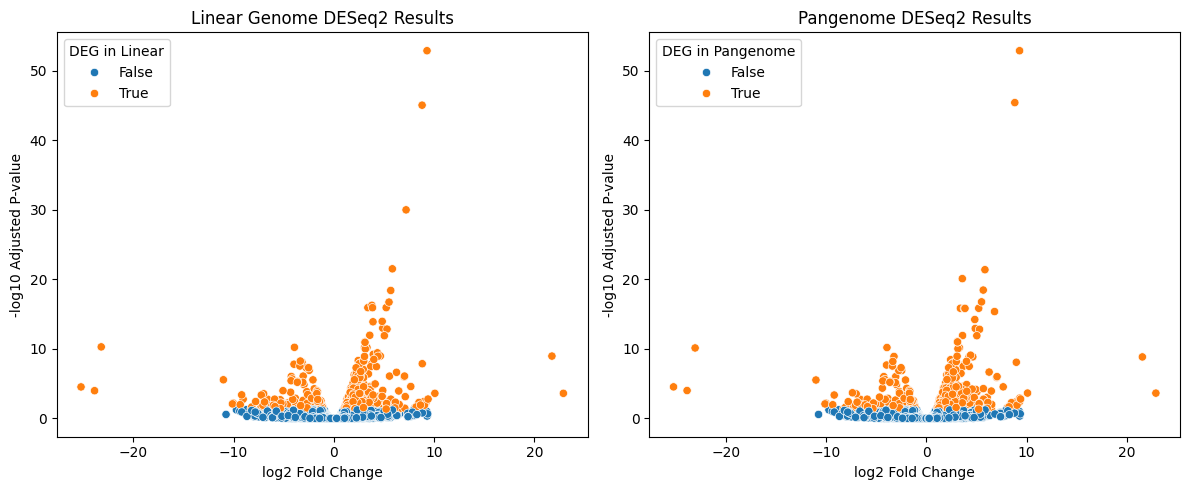

In [10]:
# Side-by-side volcano plots (linear and pangenome) with DEGs highlighted
plt.figure(figsize=(12, 5))
# linear genome volcano plot
plt.subplot(1, 2, 1)
sns.scatterplot(data=merged_degs, x="log2FoldChange_linear", y=-np.log10(merged_degs["padj_linear"]), hue="DE_linear",)
plt.title("Linear Genome DESeq2 Results")
plt.xlabel("log2 Fold Change")
plt.ylabel("-log10 Adjusted P-value")
plt.legend(title="DEG in Linear", loc="upper left")
# pangenome volcano plot
plt.subplot(1, 2, 2)
sns.scatterplot(data=merged_degs, x="log2FoldChange_pangenome", y=-np.log10(merged_degs["padj_pangenome"]), hue="DE_pangenome",)
plt.title("Pangenome DESeq2 Results")
plt.xlabel("log2 Fold Change")
plt.ylabel("-log10 Adjusted P-value")
plt.legend(title="DEG in Pangenome", loc="upper left")
plt.tight_layout()
plt.show()

In [20]:
rescue_df.groupby("DEG_status")["variants_per_kb"].mean()

DEG_status
both         3.073710
linear       6.558711
neither      2.893627
pangenome    7.156365
Name: variants_per_kb, dtype: float64

In [34]:
rescue_df.groupby("DEG_status")["mean_rescue"].describe()

,count,mean,std,min,25%,50%,75%,max
DEG_status,,,,,,,,
both,638.0,0.038534,0.118866,-0.151785,0.000135,0.001607,0.016602,1.635844
linear,9.0,0.418181,0.793852,0.000000,0.005941,0.175850,0.382896,2.494954
neither,19912.0,0.045623,0.213191,-3.650126,0.000010,0.000667,0.008329,6.153107
pangenome,23.0,0.529936,0.790996,-0.100764,0.045016,0.255753,0.454513,2.608373


<Axes: xlabel='DEG_status', ylabel='variants_per_kb'>

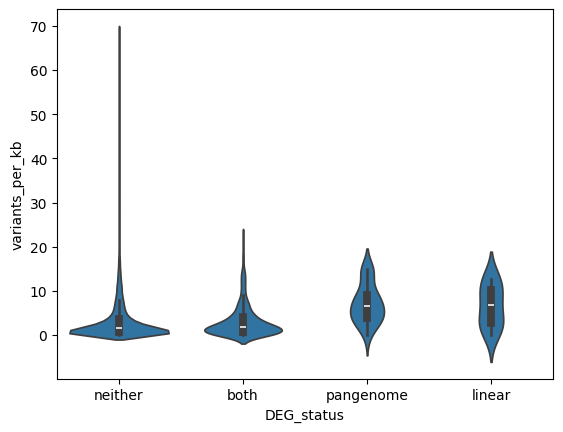

In [16]:
sns.violinplot(data=rescue_df, x="DEG_status", y="variants_per_kb")

<Axes: xlabel='DEG_status', ylabel='mean_rescue'>

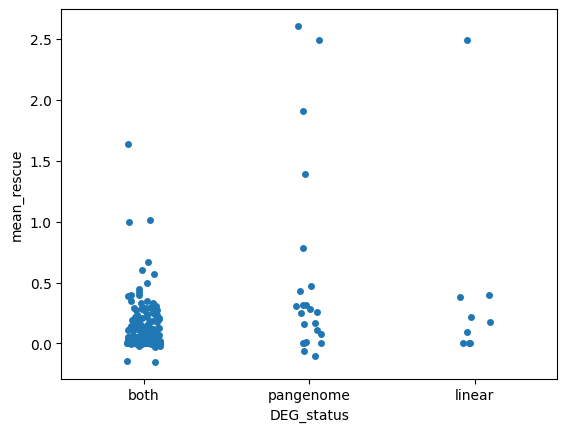

In [30]:
sns.stripplot(data=rescue_df[rescue_df["DEG_status"] != "neither"], x="DEG_status", y="mean_rescue")
# plt.ylim(-0.5, 4)

In [33]:
rescue_df.loc["AT2G44560"].to_json()

'{"mean_rescue":0.0,"std_rescue":null,"n_samples":1,"exonic_bp":1712,"variant_count":7,"variants_per_kb":4.0887850467,"log2FoldChange_linear":5.837913792,"padj_linear":0.0734554336,"log2FoldChange_pangenome":5.9868628574,"padj_pangenome":0.0437686056,"DEG_status":"pangenome","DE_linear":false,"DE_pangenome":true,"Gene description":"glycosyl hydrolase 9B11","Gene name":"GH9B11","Chromosome\\/scaffold name":"2","Gene start (bp)":18391753.0,"Gene end (bp)":18393729.0}'